# **From Seven to Two: Exploring 65 Years of Fertility in the Philippines** 

### *A Time-Series Exploration of Trend, Seasonality, Structural Breaks, Cyclicity, Stationarity, and Noise*

Author: Mariane Charisse E. Cañete ( DS4A )

### **Field:** Social Science
### **Indicator:** Total Fertility Rate (Births per Woman)

## 1. **INTRODUCTION**

For more than six decades, one demographic number has quietly transformed Philippine society.

In 1960, the average Filipino woman had nearly seven children. By 2024, the country's total fertility rate had fallen to below two children per woman—crossing the replacement-level threshold along the way.

But a falling line alone does not tell the whole story.

> ### Has Philippine fertility simply been declining—or has the country's demographic behavior fundamentally changed over time?

Did fertility fall at a constant rate? Did particular historical periods change the direction or speed of demographic change? Does fertility move in cycles? Does it return to a historical average? And which movements represent meaningful social change rather than ordinary year-to-year variation?

This case study investigates the Philippine Total Fertility Rate from 1960 to 2024 through the six characteristics of time series data:
- **Trend** — identifying the long-term direction of fertility over the 65-year period.
- **Seasonality** — determining whether a recurring pattern exists at regular intervals.
- **Cyclicity** — looking for longer-term fluctuations around the overall trend.
- **Structural Breaks** — identifying periods where the level or behavior of the series may have changed.
- **Stationarity / Mean-Reversion** — examining whether the series fluctuates around a relatively stable level or changes systematically over time.
- **Noise** — considering the irregular variation that remains after accounting for the more systematic patterns.

The goal is not simply to show that fertility has declined. It is to look more closely at how that decline occurred, determine which time-series characteristics are visible in the data, and use those characteristics to better understand the long-term behavior of fertility in the Philippines.

**Data Source:** World Bank, World Development Indicators, Total Fertility Rate (SP.DYN.TFRT.IN), Philippines, 1960–2024, compiled by FRED.

## 2. **DATASET**

Before we can understand whether Philippine fertility has fundamentally changed, we first need a long enough historical record to understand what "normal" fertility behavior looked like.

For analysis, we examine the **Philippine Total Fertility Rate from 1960 to 2024**.

The Total Fertility Rate measures the average number of children a woman would have over her lifetime based on current age-specific fertility patterns. Because fertility changes slowly and reflects long-term social, economic, cultural, and policy developments, it provides a useful indicator for observing demographic transformation over time.

The dataset gives us **65 annual observations**, allowing us to examine:

* long-term demographic movement;
* changes in the pace of fertility decline;
* whether the series returns to a stable historical level;
* possible structural turning points;
* evidence of cycles; and
* small irregular movements around the larger demographic pattern.

Before interpreting any statistical result, however, we first need to meet are working with.

The dataset contains the total fertility rate of the Philippines, measured as the average number of births per woman. The data were obtained from **The World Bank**, which provides annual fertility-rate observations beginning in 1960.

After selecting the Philippines and removing the missing observation for 2025, the final analytical series covers 1960 to 2024, giving us 65 consecutive annual observations. Because the observations are recorded chronologically at a regular annual interval, the dataset is suitable for examining the behavior of the fertility rate as a time series.

### Variables

| Variable | Description |
|---|---|
| `Year` | Year of observation |
| `Fertility Rate` | Total number of births per woman |

The analysis focuses on Fertility Rate as the variable of interest, while Year serves as the time index that places each observation in chronological order.

### What This Data Allows Us to See

The annual structure of the dataset allows us to investigate how fertility has changed over a period of more than six decades. In particular, it provides enough observations to examine long-term trends, changes in variability, possible structural shifts, and other characteristics of the series.

There is, however, an important limitation to keep in mind. Because the observations are recorded once per year, the dataset cannot reveal patterns that occur within a year. Monthly or quarterly data would be needed to properly investigate intra-anannot capture it.


## 3. **IMPORT AND DATA PREPARATION**

The dataset was checked for missing values, duplicate observations, and chronological ordering. After preparation, the analysis uses the annual fertility observations from 1960 to 2024.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
FILE_PATH = "API_SP.DYN.TFRT.IN_DS2_EN_csv_v2_33381.csv"

df = pd.read_csv(FILE_PATH, skiprows=4)
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,4.567000,4.422000,4.262000,4.107000,3.940000,3.797000,...,1.785000,1.732000,1.701000,1.662000,1.631000,1.615000,1.602000,1.606000,NaN,NaN
1,Africa Eastern and Southern,AFE,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.650310,6.667308,6.688246,6.709226,6.724930,6.737459,...,4.569915,4.521454,4.471351,4.412999,4.350691,4.287080,4.223861,4.164044,NaN,NaN
2,Afghanistan,AFG,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,7.282000,7.284000,7.292000,7.302000,7.304000,7.305000,...,5.433000,5.327000,5.238000,5.145000,5.039000,4.932000,4.840000,4.761000,NaN,NaN
3,Africa Western and Central,AFW,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.468882,6.478345,6.492276,6.500230,6.516724,6.532705,...,5.099256,4.962885,4.829455,4.707739,4.638139,4.563817,4.498196,4.416450,NaN,NaN
4,Angola,AGO,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.708000,6.790000,6.872000,6.954000,7.036000,7.116000,...,5.600000,5.519000,5.442000,5.371000,5.304000,5.209000,5.124000,5.048000,NaN,NaN


--- 

The downloaded World Bank dataset is structured in wide format, where each country occupies a row and each year is represented by a separate column. For time-series analysis, I transform the Philippine observations into long format, where each year becomes an individual observation.

The dataset is then filtered to retain the Philippines using its country code **(PHL)**. Next is reshaping the yearly columns from 1960 to 2025 into two variables: `Year` and `Fertility_Rate`.

The 2025 observation contains a missing value, so it is excluded from the final analysis. After cleaning, the resulting time series contains annual fertility-rate observations from 1960 to 2024.

In [3]:
philippines = df[df["Country Code"] == "PHL"].copy()
philippines.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
186,Philippines,PHL,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,6.996,6.994,6.98,6.952,6.886,6.799,...,2.525,2.378,2.215,2.075,1.95,1.929,1.916,1.894,NaN,NaN


In [4]:
year_columns = [str(year) for year in range(1960, 2026)]

philippines_long = philippines.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Fertility_Rate"
)

philippines_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Fertility_Rate
0,Philippines,PHL,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,6.996
1,Philippines,PHL,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1961,6.994
2,Philippines,PHL,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1962,6.980
3,Philippines,PHL,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1963,6.952
4,Philippines,PHL,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1964,6.886


In [5]:
philippines_long["Year"] = pd.to_numeric(
    philippines_long["Year"],
    errors="coerce"
)

In [6]:
philippines_long = philippines_long.dropna(subset=["Fertility_Rate"])

In [7]:
philippines_long = philippines_long.sort_values("Year")

In [8]:
ts = philippines_long[["Year", "Fertility_Rate"]].copy()

ts = ts.set_index("Year")

ts.head()

,Fertility_Rate
Year,
1960,6.996
1961,6.994
1962,6.980
1963,6.952
1964,6.886


In [9]:
print("First year:", ts.index.min())
print("Last year:", ts.index.max())
print("Number of observations:", len(ts))

First year: 1960
Last year: 2024
Number of observations: 65


In [10]:
print("=== DATASET OVERVIEW ===")

print(f"Time Horizon:   {ts.index[0]} to {ts.index[-1]}")
print(f"Total Periods:  {len(ts)} annual observations")
print(f"Columns:        {list(ts.columns)}")

print()

print("--- First 5 Records (Head) ---")
print(ts.head())

print()

print("--- Last 5 Records (Tail) ---")
print(ts.tail())

print()

print("--- Dataframe Information & Types ---")
ts.info()

print()

print("--- Summary Statistics ---")
print(ts.describe())

=== DATASET OVERVIEW ===
Time Horizon:   1960 to 2024
Total Periods:  65 annual observations
Columns:        ['Fertility_Rate']

--- First 5 Records (Head) ---
      Fertility_Rate
Year                
1960           6.996
1961           6.994
1962           6.980
1963           6.952
1964           6.886

--- Last 5 Records (Tail) ---
      Fertility_Rate
Year                
2020           2.075
2021           1.950
2022           1.929
2023           1.916
2024           1.894

--- Dataframe Information & Types ---
<class 'pandas.DataFrame'>
RangeIndex: 65 entries, 1960 to 2024
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Fertility_Rate  65 non-null     float64
dtypes: float64(1)
memory usage: 652.0 bytes

--- Summary Statistics ---
       Fertility_Rate
count       65.000000
mean         4.396215
std          1.482235
min          1.894000
25%          3.401000
50%          4.161000
75%          5.505

---

Before running a statistical test or assigning a time-series characteristic, we first examine the shape, coverage, and overall behavior of the Philippine fertility record.

The dataset contains annual observations from **1960 to 2024**, covering more than six decades of demographic change.

### **Initial Data Observations**

1. **Total Fertility Rate:** The series begins at nearly **seven children per woman** in 1960 and falls to below **two children per woman** by 2024.

2. **Long-Term Direction:** The movement is overwhelmingly downward. Unlike many economic or environmental series, fertility does not repeatedly rise and fall around a stable center.

3. **Replacement-Level Threshold:** The series eventually crosses approximately **2.1 births per woman**, the commonly used replacement-level threshold in the absence of migration.

4. **Annual Frequency:** Because the data is recorded only once per year, the series is useful for studying long-term demographic behavior but cannot directly reveal within-year patterns such as monthly or quarterly seasonality.

The first plot gives us the most important clue of the entire investigation.

## **The First Look: What the Series Tell Us**

Before examining each time-series characteristic individually, we first let the data speak for itself.

The fertility rate is plotted against year to reveal how the series behaves over time. This first visualization allows us to look for broad changes in direction, repeated patterns, unusual movements, and possible changes in the overall behavior of the series.

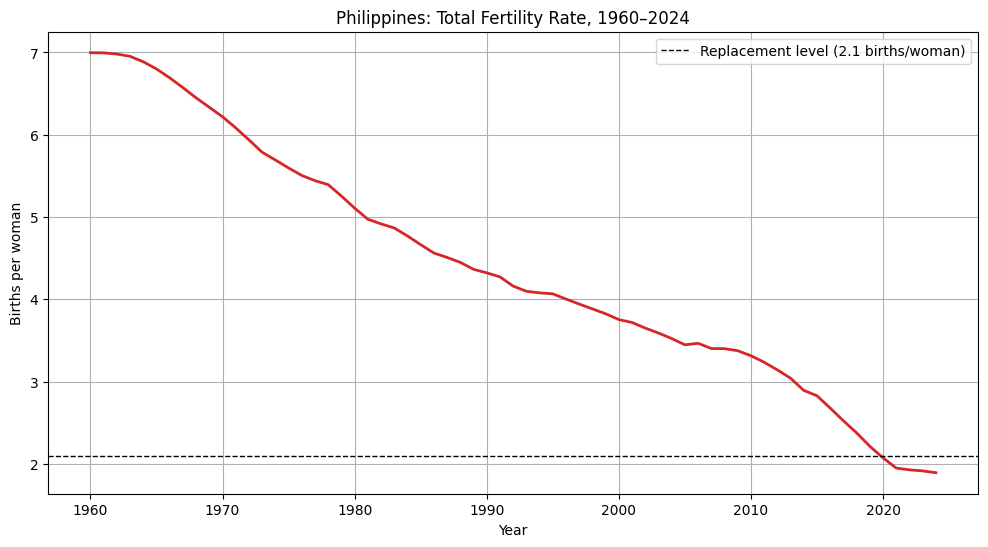

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    ts.index,
    ts["Fertility_Rate"],
    color="tab:red",
    linewidth=2
)

ax.axhline(
    2.1,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Replacement level (2.1 births/woman)"
)

ax.set_title("Philippines: Total Fertility Rate, 1960–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Births per woman")
ax.legend()
ax.grid()

plt.show()

### The historical picture is striking.

- **1960s:** Philippine fertility begins at an exceptionally high level, with the average woman having nearly seven children.
- **1970s–2000s:** Fertility continues to fall, although the pace of decline becomes slower during some periods.
- **2010s:** The downward movement accelerates again, pushing the country closer to replacement-level fertility.
- **Around 2019–2020:** The series crosses the approximate replacement-level threshold of 2.1 children per woman.
- **2020–2024:** Fertility continues downward, although the pace of decline appears slower than during the preceding decade.

The series therefore does not appear to fluctuate randomly around a stable level. Instead, the entire historical record moves downward across multiple decades.

The decline is also not perfectly uniform.

Some periods appear relatively gradual, while others show a noticeably faster decline. This raises an important question:

> ### Are we looking at one continuous demographic trend—or did the behavior of Philippine fertility change at different points in history?

The raw series gives us our first major clue: **Philippine fertility is dominated by a strong long-term movement.** The next step is to investigate that movement systematically.


In [12]:
start_value = ts["Fertility_Rate"].iloc[0]
end_value = ts["Fertility_Rate"].iloc[-1]

absolute_change = end_value - start_value

percent_change = (
    (end_value - start_value)
    / start_value
) * 100

print("Starting fertility rate:", round(start_value, 2))
print("Ending fertility rate:", round(end_value, 2))
print("Absolute change:", round(absolute_change, 2))
print("Percentage change:", round(percent_change, 2), "%")

Starting fertility rate: 7.0
Ending fertility rate: 1.89
Absolute change: -5.1
Percentage change: -72.93 %


### **Quantifying the Change**

The initial visualization suggests a substantial long-term decline in Philippine fertility. To quantify the magnitude of this change, we compare the first and last observations in the time series.

The fertility rate declined from **7.00 births per woman** at the beginning of the series to **1.89 births per woman** at the end.

This represents an **absolute decrease of approximately 5.10 births per woman**, or a **72.93% decline** relative to the starting fertility rate.

This calculation strengthens the initial visual observation. The downward movement is not a small short-term fluctuation: over the 65-year period, Philippine fertility fell by nearly three-quarters of its initial level.

> **The first clue is therefore clear: the fertility time series has experienced a substantial long-term decline.**

However, this comparison only describes the difference between the beginning and end of the historical record. It does not yet explain whether the decline occurred consistently, whether the series is stationary, or whether its behavior changed across different periods. These questions are investigated in the following sections.


## 4. **Characteristics of the Time Series**

The initial observation provides a general view of how the fertility rate has changed over time. However, identifying a pattern from the overall movement is only the first step in understanding a time series. To examine the behavior of the series more systematically, we now investigate the **key characteristics of time-series data** introduced in the course.

Each characteristic provides a different perspective on the behavior of the fertility rate and helps describe how the series changes across time. The following sections examine these characteristics individually, using the Philippine fertility-rate series to illustrate and interpret each one.


### 4.1 **Characteristic 1: Trend — Is Fertility Moving in One Persistent Direction?**

A **trend** is the long-term increase or decrease in the level of a time series.

The raw fertility record already points to a strong downward movement. However, a declining line alone does not fully describe the behavior of the series. The larger question is whether this downward movement represents the dominant long-term direction of Philippine fertility or merely a temporary change surrounded by short-term fluctuations.

For Philippine fertility, the central question is:

> **Is the decline temporary—or does it represent the dominant direction of the entire 65-year series?**

**Why it matters here:** This is the foundation clue for the whole investigation. If fertility only ever moved in one dominant direction with no meaningful deceleration or reversal, later claims about a "changed demographic behavior" would rest on shakier ground — a straight decline could still just be "simple decline." Confirming trend dominance here is what licenses moving on to test whether the level (stationarity) and pace (structural change) also changed, not just the direction.

To examine the overall movement of Philippine fertility, the series is viewed from three perspectives.

First, the annual fertility rate presents the actual year-to-year observations, including smaller fluctuations within the historical record. Second, a 5-year centered rolling average smooths these short-term movements, making the underlying long-term trajectory easier to observe. Finally, a descriptive linear trend line summarizes the overall direction of change across the complete observation period.

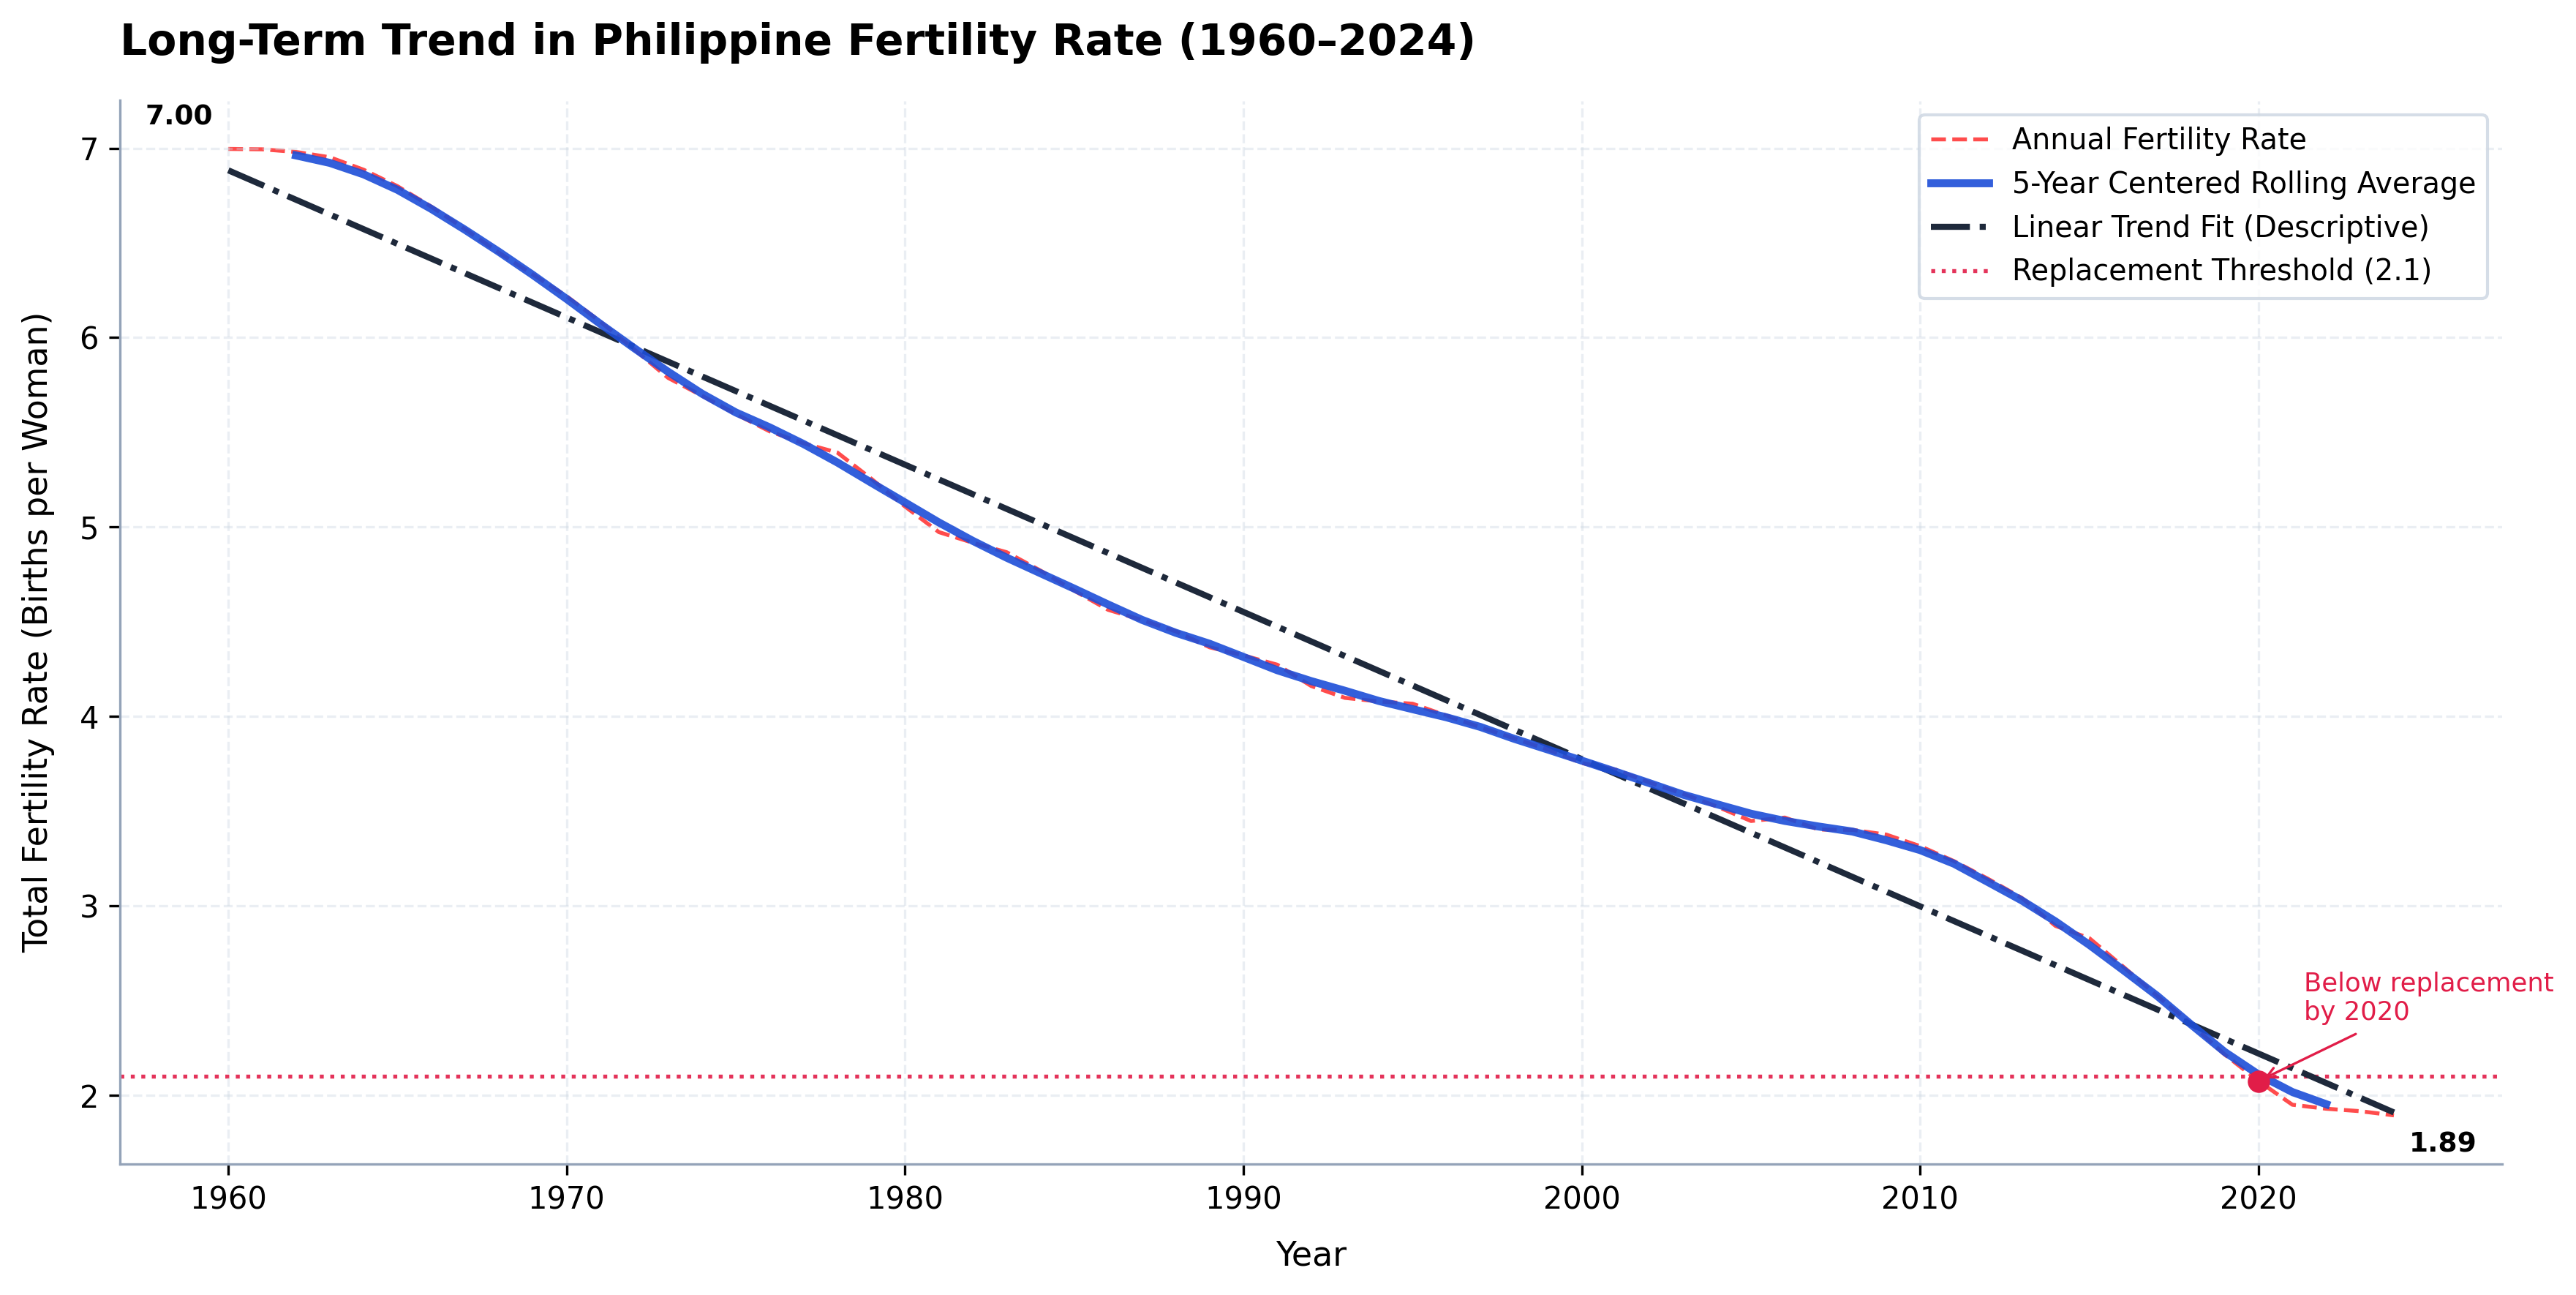

In [35]:
ts["Rolling_5yr"] = ts["Fertility_Rate"].rolling(window=5, center=True).mean()
x = np.arange(len(ts))
coeffs = np.polyfit(x, ts["Fertility_Rate"], deg=1)
trend_line = np.polyval(coeffs, x)

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

COLOR_ANNUAL     = "red"  
COLOR_ROLLING    = "#1d4ed8"  
COLOR_LINEAR     = "#1e293b"  
COLOR_BENCHMARK  = "#e11d48"  

ax.plot(ts.index, ts["Fertility_Rate"], color=COLOR_ANNUAL,
        linewidth=1.3, alpha=0.7, linestyle="--", label="Annual Fertility Rate", zorder=1)

ax.plot(ts.index, ts["Rolling_5yr"], color=COLOR_ROLLING,
        linewidth=2.6, alpha=0.9, label="5-Year Centered Rolling Average", zorder=3)

ax.plot(ts.index, trend_line, color=COLOR_LINEAR,
        linewidth=2, linestyle="-.", label="Linear Trend Fit (Descriptive)", zorder=2)

ax.axhline(y=2.1, color=COLOR_BENCHMARK, linestyle=":", linewidth=1.3,
           alpha=0.9, label="Replacement Threshold (2.1)", zorder=1)

below = ts["Fertility_Rate"] <= 2.1
if below.any():
    cross_year = ts.index[below.argmax()]
    cross_val = ts.loc[cross_year, "Fertility_Rate"]
    ax.scatter([cross_year], [cross_val], color=COLOR_BENCHMARK, zorder=4, s=40)
    ax.annotate(f"Below replacement\nby {cross_year}",
                xy=(cross_year, cross_val), xytext=(15, 20),
                textcoords="offset points", fontsize=8.5, color=COLOR_BENCHMARK,
                arrowprops=dict(arrowstyle="->", color=COLOR_BENCHMARK, lw=0.8))

ax.annotate(f"{ts['Fertility_Rate'].iloc[0]:.2f}", xy=(ts.index[0], ts["Fertility_Rate"].iloc[0]),
            xytext=(-5, 8), textcoords="offset points", fontsize=9, fontweight="bold", ha="right")
ax.annotate(f"{ts['Fertility_Rate'].iloc[-1]:.2f}", xy=(ts.index[-1], ts["Fertility_Rate"].iloc[-1]),
            xytext=(5, -12), textcoords="offset points", fontsize=9, fontweight="bold")

ax.set_title("Long-Term Trend in Philippine Fertility Rate (1960–2024)",
              fontsize=14, fontweight="bold", pad=15, loc="left")
ax.set_xlabel("Year", fontsize=11, labelpad=8)
ax.set_ylabel("Total Fertility Rate (Births per Woman)", fontsize=11, labelpad=8)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#94a3b8")
ax.spines["bottom"].set_color("#94a3b8")

ax.grid(True, linestyle="--", alpha=0.4, color="#cbd5e1")
ax.legend(frameon=True, facecolor="white", edgecolor="#cbd5e1", fontsize=9.5, loc="upper right")

plt.tight_layout()
plt.show()

--- 

### Key Observations

* **Persistent Decline:** Fertility steadily decreased from **7.00 births per woman in 1960 to 1.89 in 2024**.
* **Below Replacement Level:** The fertility rate falls below the **2.1 replacement-level threshold** around 2018–2020 and remains below it afterward.
* **Changing Rate of Decline:** The downward movement is not perfectly linear, with periods of faster and slower decline across the series.
* **Consistent Smoothed Movement:** The 5-year centered rolling average follows the overall downward pattern of the annual fertility rate.

### **Reading the Trend**

The rolling average confirms what the raw series suggested: the dominant behavior of Philippine fertility is a long-term downward trend. The movement is not a short-lived decline followed by a return to previous levels. Instead, the baseline itself continues to move downward across the historical record. This is important because a time series with a strong trend behaves differently from one that fluctuates around a stable center.

The Philippines did not simply experience a few years of unusually low fertility.

> **The historical level of fertility itself changed.**

That observation leads directly to the next question: if the baseline keeps moving, can fertility be considered stationary?


### 4.2 **Characteristic 2: Stationarity — Does Fertility Fluctuate Around a Stable Level??**

To answer this, the series is examined for stationarity. While the trend analysis describes the overall direction of fertility over time, stationarity focuses on whether the statistical properties of the series remain relatively stable.

A stationary time series generally fluctuates around a stable level, with relatively consistent mean and variance over time. A non-stationary series, in contrast, may exhibit a changing level, persistent trend, or unit-root behavior.

For the Philippine fertility series, the substantial change in its level—from approximately 7 births per woman in 1960 to 1.89 in 2024—suggests that the series may not fluctuate around a single stable historical level.

To formally assess this, the **Augmented Dickey-Fuller (ADF) test** is applied.

#### HYPOTHESES

The ADF test evaluates the following hypotheses:

- **Null hypothesis (H₀):** The series has a unit root and is non-stationary.
- **Alternative hypothesis (H₁):** The series does not have a unit root and is stationary.

In [24]:
adf_result = adfuller(ts["Fertility_Rate"])

print("=== ADF TEST: ORIGINAL FERTILITY SERIES ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

=== ADF TEST: ORIGINAL FERTILITY SERIES ===
ADF Statistic: -1.2535
p-value:       0.6502

Critical Values:
1%: -3.5387
5%: -2.9086
10%: -2.5919


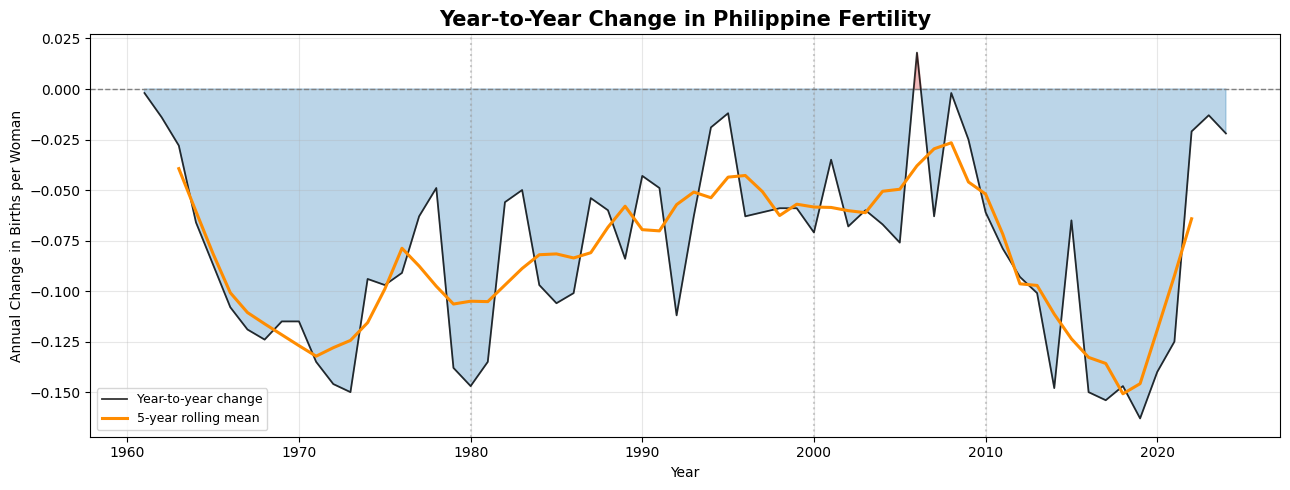

In [33]:
ts["First_Difference"] = ts["Fertility_Rate"].diff()

fig, ax = plt.subplots(figsize=(13, 5))

# main series
ax.plot(ts.index, ts["First_Difference"], color="black",
        linewidth=1.3, alpha=0.8, zorder=3, label="Year-to-year change")

# fill by sign
ax.fill_between(ts.index, ts["First_Difference"], 0,
                 where=(ts["First_Difference"] >= 0),
                 color="tab:red", alpha=0.3, interpolate=True)
ax.fill_between(ts.index, ts["First_Difference"], 0,
                 where=(ts["First_Difference"] < 0),
                 color="tab:blue", alpha=0.3, interpolate=True)

rolling_mean = ts["First_Difference"].rolling(window=5, center=True).mean()
ax.plot(ts.index, rolling_mean, color="darkorange", linewidth=2.2,
         label="5-year rolling mean", zorder=4)

ax.axhline(0, linestyle="--", linewidth=1, color="gray", zorder=2)

for year in [1980, 2000, 2010]:
    ax.axvline(year, linestyle=":", color="gray", alpha=0.4, zorder=1)

ax.set_title("Year-to-Year Change in Philippine Fertility", fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Change in Births per Woman")
ax.grid(alpha=0.3)
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
diff_series = ts["First_Difference"].dropna()

adf_diff = adfuller(diff_series)

print("=== ADF TEST: FIRST-DIFFERENCED SERIES ===")
print(f"ADF Statistic: {adf_diff[0]:.4f}")
print(f"p-value:       {adf_diff[1]:.4f}")

=== ADF TEST: FIRST-DIFFERENCED SERIES ===
ADF Statistic: -3.8458
p-value:       0.0025


### **The Stationarity Verdict**

The ADF test does not provide evidence that the original fertility series is stationary. With a p-value of approximately **0.65**, we fail to reject the null hypothesis of non-stationarity.

This matches what we observed visually.

Philippine fertility does not fluctuate around one stable historical average. A fertility rate of seven births per woman may have been typical during the early part of the series, but it is clearly not the demographic "normal" of the Philippines today.

After first differencing, however, the ADF result changes substantially. The p-value falls to approximately **0.002**, indicating that the year-to-year changes are much more stable than the original fertility levels.

The interpretation is important:

> #### **The fertility level is non-stationary because the demographic baseline has changed across time.**

The Philippines has therefore experienced a structural demographic transition rather than temporary deviations around a permanent fertility average.


## 4.3 Characteristic 3: Seasonality — Does Fertility Follow a Repeating Calendar Pattern?

Seasonality refers to a pattern that repeats at a fixed and predictable interval, such as monthly rainfall patterns or quarterly changes in economic activity.

However, the Philippine fertility dataset contains only **one observation per year**.

This creates an important limitation.

Because there are no monthly or quarterly observations, the dataset cannot directly reveal within-year demographic seasonality. A yearly fertility rate represents an annual summary rather than a sequence of repeated observations within the same calendar cycle.

Therefore:

> **No meaningful seasonal pattern can be identified from this annual dataset.**

This does not mean that fertility behavior cannot have seasonal influences at a more detailed monthly level. It means that the current data frequency is too coarse to observe them.

**The absence of observable seasonality is therefore partly a characteristic of the dataset itself.**

## 4.4 Characteristic 4: Structural Change — Does the Pace of Fertility Decline Change Over Time?

Structural change refers to a situation in which the behavior of a time series changes across different periods. Although the overall trend may remain in the same direction, the **rate or pace of change** may not remain constant throughout the entire historical period.

The Philippine fertility dataset covers a long period from **1960 to 2024**.

This makes it possible that fertility did not decline at exactly the same pace across all decades.

To explore this possibility, the series was divided into four historical periods:

* **1960–1979**
* **1980–1999**
* **2000–2009**
* **2010–2024**

These periods were selected as an exploratory segmentation of the long historical series to facilitate comparisons across earlier and more recent stages of fertility decline. The boundaries should therefore not be interpreted as statistically confirmed structural breakpoints.

A simple linear regression slope was calculated for each period to estimate the average annual rate of fertility change. Comparing these slopes helps determine whether the decline was relatively consistent or whether some periods experienced faster or slower demographic change.

This approach provides an exploratory assessment rather than a formal statistical test for structural breaks.

Therefore:

> **The fertility trend should not automatically be assumed to decline at one constant rate throughout the entire 1960–2024 period.**

The analysis of the different historical periods helps identify possible changes in the pace of fertility decline.

**The direction of fertility change may remain broadly downward, while the speed of demographic change may vary across different periods.**


In [27]:
from scipy.stats import linregress

periods = {
    "1960–1979": (1960, 1979),
    "1980–1999": (1980, 1999),
    "2000–2009": (2000, 2009),
    "2010–2024": (2010, 2024)
}

results = []

for label, (start, end) in periods.items():

    subset = ts.loc[start:end, "Fertility_Rate"]

    slope, intercept, r_value, p_value, std_err = linregress(
        subset.index,
        subset.values
    )

    results.append({
        "Period": label,
        "Annual Slope": slope,
        "Change Across Period": subset.iloc[-1] - subset.iloc[0]
    })

period_summary = pd.DataFrame(results)

period_summary

,Period,Annual Slope,Change Across Period
0,1960–1979,-0.103033,-1.741
1,1980–1999,-0.065626,-1.283
2,2000–2009,-0.044358,-0.378
3,2010–2024,-0.115325,-1.421


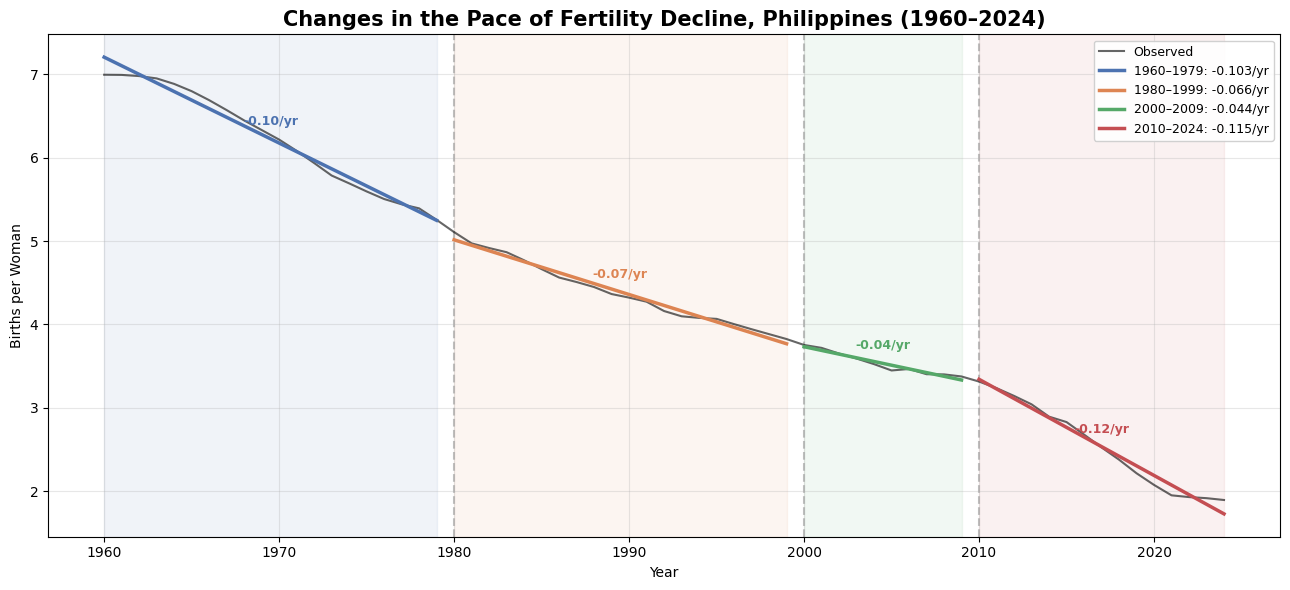

In [32]:
periods = {
    "1960–1979": (1960, 1979),
    "1980–1999": (1980, 1999),
    "2000–2009": (2000, 2009),
    "2010–2024": (2010, 2024),
}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(ts.index, ts["Fertility_Rate"], color="black",
        linewidth=1.5, alpha=0.6, label="Observed", zorder=2)

for (label, (start, end)), color in zip(periods.items(), colors):
    subset = ts.loc[start:end, "Fertility_Rate"]
    slope, intercept, r, p, se = linregress(subset.index, subset.values)

    ax.axvspan(start, end, color=color, alpha=0.08, zorder=0)

    fitted = intercept + slope * subset.index
    ax.plot(subset.index, fitted, color=color, linewidth=2.5,
             zorder=3, label=f"{label}: {slope:+.3f}/yr")

    mid_x = (start + end) / 2
    mid_y = intercept + slope * mid_x
    ax.annotate(f"{slope:+.2f}/yr", xy=(mid_x, mid_y),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold", color=color)

for year in [1980, 2000, 2010]:
    ax.axvline(year, linestyle="--", color="gray", alpha=0.5, zorder=1)

ax.set_title("Changes in the Pace of Fertility Decline, Philippines (1960–2024)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Births per Woman")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### **Reading the Structural Changes**

The Philippine fertility series does not appear to decline at exactly the same pace throughout the entire 65-year period.

Instead, the historical record suggests that the demographic process changed across different periods. Some decades show relatively gradual declines, while later periods show a more pronounced movement toward below-replacement fertility.

This does not automatically prove a formal statistical structural break. However, for an observational case study, it provides evidence that the series should not be interpreted as one perfectly uniform downward line.

> **The direction of change remains broadly downward, but the speed of demographic change appears to vary across history.**

This distinction is important.

A trend tells us that fertility has been declining.

Structural change suggests that the demographic process producing that decline may not have behaved identically during every historical period.

---

## 4.5 Characteristic 5: Cyclicity — Does Fertility Follow a Repeating Long-Term Cycle?

Cyclicity refers to long-term rises and falls that occur over periods longer than a seasonal cycle. Unlike seasonality, however, cycles do not necessarily repeat at fixed intervals.

The Philippine fertility series is dominated by a persistent downward demographic trend, so the trend component was removed to examine whether additional long-term structure remains underneath it. A linear trend was fit first, followed by a polynomial (degree 2) trend to check whether the shape of the trend itself was responsible for any remaining pattern in the residuals.

Both detrending approaches produced a similar result. After removing the linear trend, the residual series showed one long, smooth swing: positive from roughly 1960–1974, a prolonged trough through the 1980s–1990s, and a rise back above zero from about 2005–2020. Refitting with a polynomial trend improved the fit only marginally (R² rose from 0.9828 to 0.9871), and the resulting residual retained essentially the same long-wavelength pattern. The autocorrelation function told the same story under both detrending methods: rather than decaying quickly to near-zero, autocorrelation declined smoothly, crossed into negative territory around a lag of 9–10 years, and remained persistently negative out to a lag of 25 years.

Because a meaningfully better-fitting nonlinear trend did not eliminate this structure, it is unlikely that the pattern is simply an artifact of an under-fit linear trend. The persistence of a smooth, long-wavelength swing in the residuals (visible in both the time-domain plot and the autocorrelation function) is more consistent with genuine low-frequency structure in Philippine fertility beyond its overall demographic decline.

At the same time, this should not be overstated as confirmed cyclicity in the strict sense. With 65 years of annual data showing roughly one full swing and part of a second, there are too few repetitions to establish that this pattern recurs at a consistent interval, which is what would be required to characterize it as a true repeating cycle rather than a single large, slow deviation from trend. A more definitive assessment would require either a longer historical record or formal spectral analysis to test for a statistically significant dominant frequency.

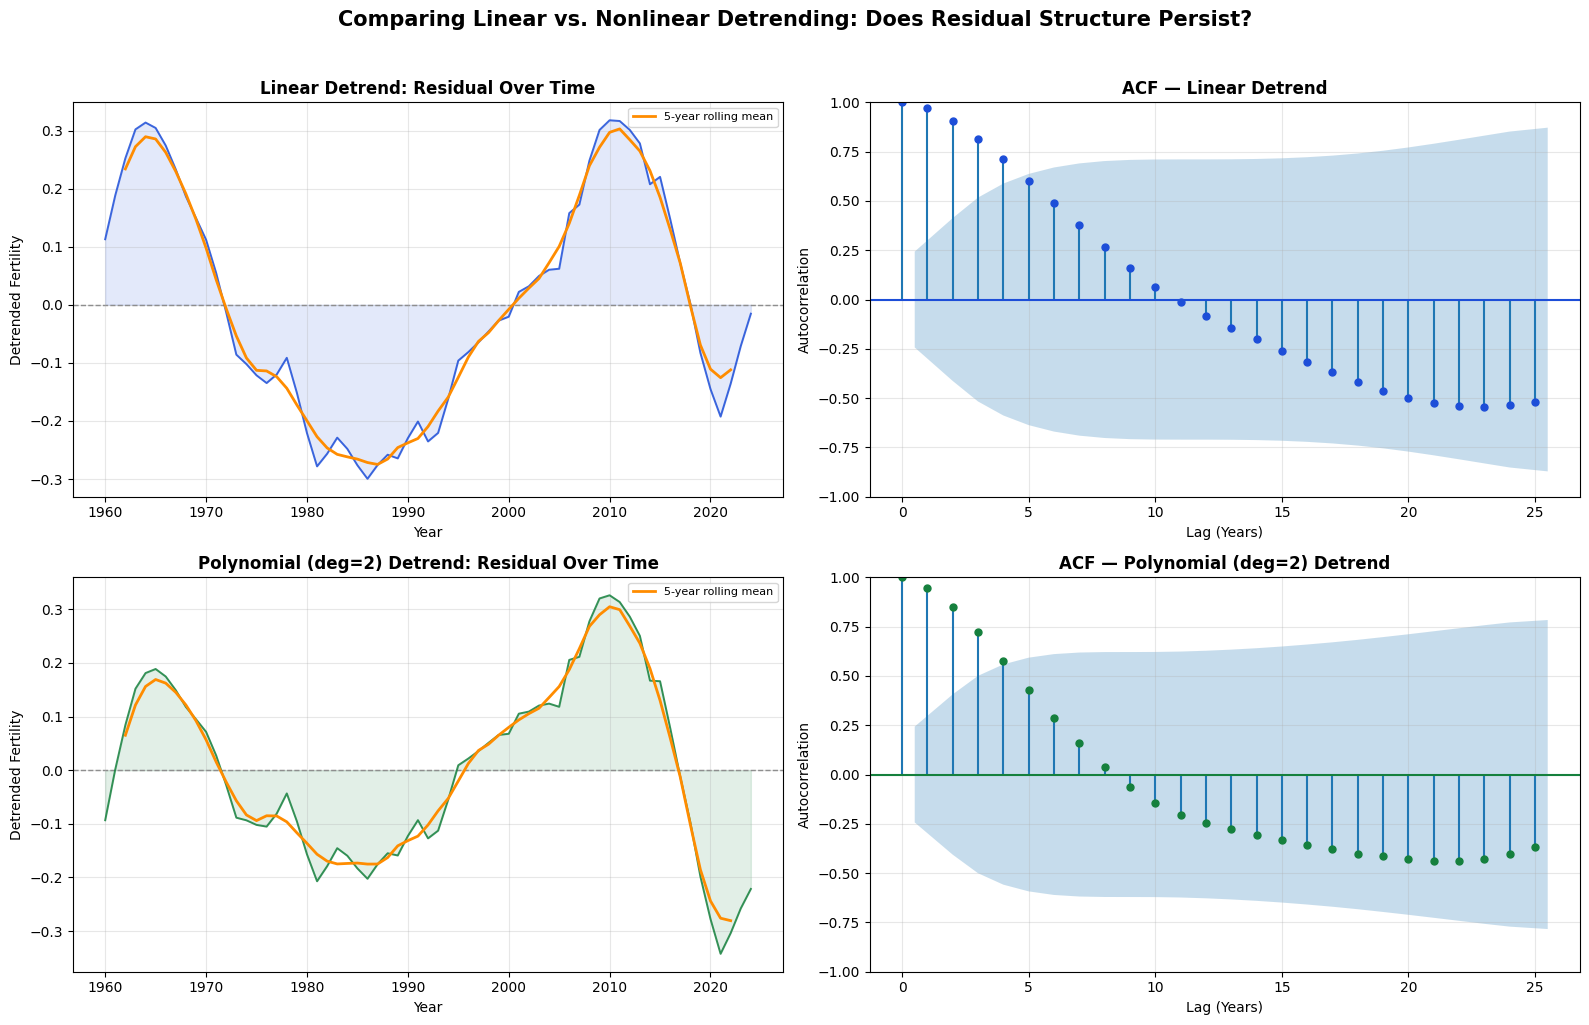

In [39]:
from statsmodels.graphics.tsaplots import plot_acf

poly_coeffs = np.polyfit(x, ts["Fertility_Rate"], deg=2)
poly_trend = np.polyval(poly_coeffs, x)
ts["Detrended_Poly"] = ts["Fertility_Rate"].values - poly_trend

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#Panel 1-Linear Detrand
ax1 = axes[0, 0]
ax1.plot(ts.index, ts["Detrended"], color="#1d4ed8", linewidth=1.4, alpha=0.85, zorder=2)
ax1.fill_between(ts.index, ts["Detrended"], 0, color="#1d4ed8", alpha=0.12, zorder=1)
rolling_linear = ts["Detrended"].rolling(window=5, center=True).mean()
ax1.plot(ts.index, rolling_linear, color="darkorange", linewidth=2,
          label="5-year rolling mean", zorder=3)
ax1.axhline(0, linestyle="--", linewidth=1, color="gray", zorder=1)
ax1.set_title("Linear Detrend: Residual Over Time", fontsize=12, fontweight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Detrended Fertility")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8, loc="upper right")

# Panel 2-ACF of linear-detrended series (existing) 
ax2 = axes[0, 1]
plot_acf(ts["Detrended"], lags=25, ax=ax2, color="#1d4ed8")
ax2.set_title("ACF — Linear Detrend", fontsize=12, fontweight="bold")
ax2.set_xlabel("Lag (Years)")
ax2.set_ylabel("Autocorrelation")
ax2.grid(alpha=0.3)

# Panel 3: Polynomial-detrended series (new)
ax3 = axes[1, 0]
ax3.plot(ts.index, ts["Detrended_Poly"], color="#15803d", linewidth=1.4, alpha=0.85, zorder=2)
ax3.fill_between(ts.index, ts["Detrended_Poly"], 0, color="#15803d", alpha=0.12, zorder=1)
rolling_poly = ts["Detrended_Poly"].rolling(window=5, center=True).mean()
ax3.plot(ts.index, rolling_poly, color="darkorange", linewidth=2,
          label="5-year rolling mean", zorder=3)
ax3.axhline(0, linestyle="--", linewidth=1, color="gray", zorder=1)
ax3.set_title("Polynomial (deg=2) Detrend: Residual Over Time", fontsize=12, fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("Detrended Fertility")
ax3.grid(alpha=0.3)
ax3.legend(fontsize=8, loc="upper right")

#Panel 4: ACF of polynomial-detrended series (new)
ax4 = axes[1, 1]
plot_acf(ts["Detrended_Poly"], lags=25, ax=ax4, color="#15803d")
ax4.set_title("ACF — Polynomial (deg=2) Detrend", fontsize=12, fontweight="bold")
ax4.set_xlabel("Lag (Years)")
ax4.set_ylabel("Autocorrelation")
ax4.grid(alpha=0.3)

fig.suptitle("Comparing Linear vs. Nonlinear Detrending: Does Residual Structure Persist?",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import r2_score

r2_linear = r2_score(ts["Fertility_Rate"], trend_line)
r2_poly = r2_score(ts["Fertility_Rate"], poly_trend)

print(f"R² — Linear trend:     {r2_linear:.4f}")
print(f"R² — Polynomial trend: {r2_poly:.4f}")

R² — Linear trend:     0.9828
R² — Polynomial trend: 0.9871


## 4.6 Characteristic 6: Noise — How Much Movement Is Just Irregular Variation?

Noise refers to irregular variation that does not form part of a clear trend, seasonal pattern, or cycle.

In the Philippine fertility series, year-to-year movements are relatively small compared with the enormous long-term decline from nearly seven births per woman to below two.

This means that the dominant signal is much larger than the irregular variation.

**Why it matters here:** This is the reality-check clue. If year-to-year noise were large relative to the long-run move, we would need to be cautious about over-interpreting the trend, stationarity, and structural-change findings above — some of what looked like a real shift could just be sampling wobble. Confirming that noise is small relative to signal is what lets us trust the other five clues rather than dismiss them as chasing statistical static.

Small annual increases or decreases should therefore be interpreted cautiously. A single year's movement does not necessarily represent a fundamental demographic reversal.

> **The long-term demographic signal is stronger than the short-term noise.**

This is one of the clearest characteristics of the series: Philippine fertility changes gradually from year to year, but the cumulative movement across decades is profound.


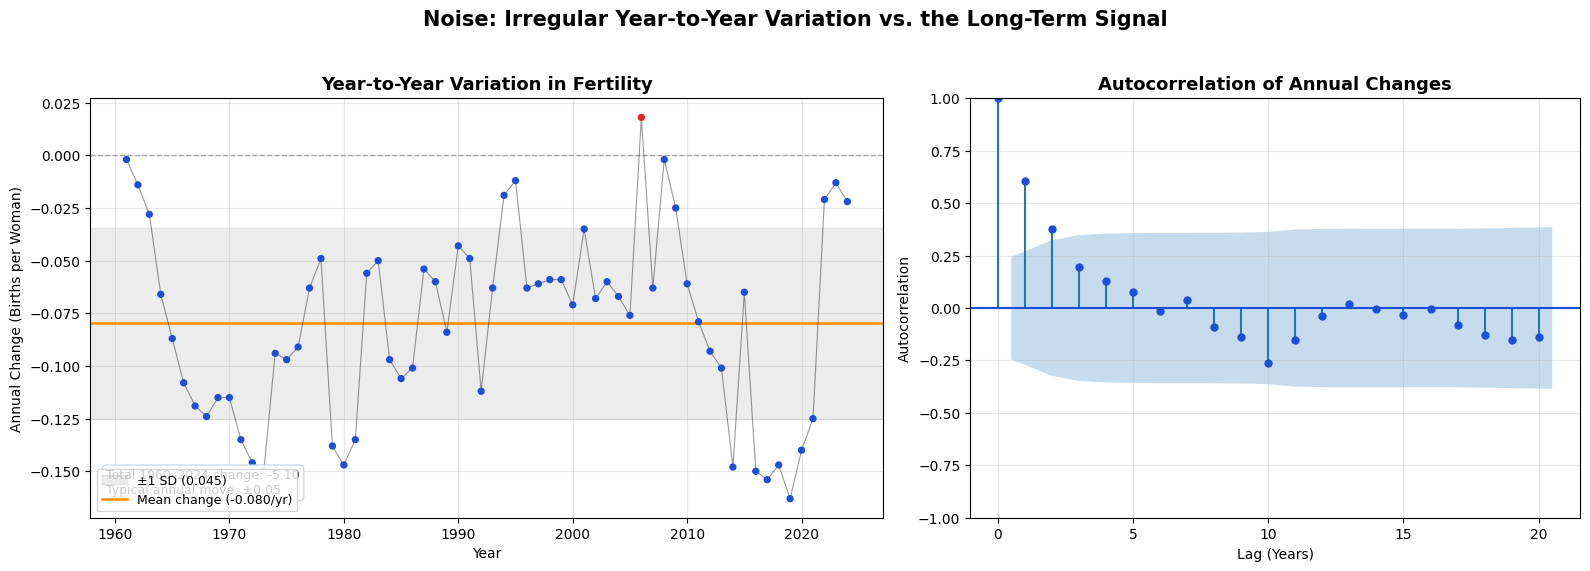

=== YEAR-TO-YEAR CHANGE SUMMARY ===
count    64.000000
mean     -0.079719
std       0.045243
min      -0.163000
25%      -0.115000
50%      -0.069500
75%      -0.053000
max       0.018000
Name: First_Difference, dtype: float64

Ratio of total long-term decline to typical annual move: 112.8x


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})

#Panel 1: Year-to-year change, with mean/std band 
ax1 = axes[0]
diff = ts["First_Difference"].dropna()
mean_diff = diff.mean()
std_diff = diff.std()

ax1.axhspan(mean_diff - std_diff, mean_diff + std_diff, color="gray", alpha=0.15,
            label=f"±1 SD ({std_diff:.3f})", zorder=0)
ax1.axhline(mean_diff, color="darkorange", linewidth=1.8, linestyle="-",
            label=f"Mean change ({mean_diff:.3f}/yr)", zorder=2)
ax1.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.7, zorder=1)

colors = np.where(ts["First_Difference"] >= 0, "#dc2626", "#1d4ed8")
ax1.scatter(ts.index, ts["First_Difference"], c=colors, s=18, zorder=3)
ax1.plot(ts.index, ts["First_Difference"], color="black", linewidth=0.8, alpha=0.4, zorder=2)

ax1.set_title("Year-to-Year Variation in Fertility", fontsize=13, fontweight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Annual Change (Births per Woman)")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=9, loc="lower left")

total_decline = ts["Fertility_Rate"].iloc[-1] - ts["Fertility_Rate"].iloc[0]
ax1.text(0.02, 0.05,
         f"Total 1960–2024 change: {total_decline:.2f}\nTypical annual move: ±{std_diff:.2f}",
         transform=ax1.transAxes, fontsize=9, va="bottom",
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cbd5e1", alpha=0.9))

#Panel 2: ACF of annual changes
ax2 = axes[1]
plot_acf(diff, lags=20, ax=ax2, color="#1d4ed8")
ax2.set_title("Autocorrelation of Annual Changes", fontsize=13, fontweight="bold")
ax2.set_xlabel("Lag (Years)")
ax2.set_ylabel("Autocorrelation")
ax2.grid(alpha=0.3)

fig.suptitle("Noise: Irregular Year-to-Year Variation vs. the Long-Term Signal",
             fontsize=15, fontweight="bold", y=1.03)

plt.tight_layout()
plt.show()

print("=== YEAR-TO-YEAR CHANGE SUMMARY ===")
print(diff.describe())
print(f"\nRatio of total long-term decline to typical annual move: "
      f"{abs(total_decline) / std_diff:.1f}x")

## **6. So, the question: What Kind of Time Series Is Philippine Fertility?**

We now have enough evidence to describe the behavior of the Philippine fertility time series.

The historical record is dominated by one overwhelming feature:

> **a long-term demographic transition from high fertility to below-replacement fertility.**

The six characteristics help explain that transformation from different perspectives.

* **Trend** tells us that fertility has moved persistently downward across more than six decades.
* **Stationarity** tells us that the fertility level does not return to one stable historical mean because the demographic baseline itself has changed.
* **Seasonality** cannot be meaningfully identified because the dataset contains annual rather than monthly or quarterly observations.
* **Structural change** suggests that the pace of fertility decline has not been perfectly uniform throughout history.
* **Cyclicity** Cyclicity shows a persistent long-wavelength swing in the detrended residuals that survives even a better-fitting nonlinear trend, suggesting some long-period structure beyond the demographic trend — though with only ~65 years of data, this cannot be confirmed as a true repeating cycle.
* **Noise** exists in the small year-to-year movements, but it is minor compared with the magnitude of the long-term decline.

Putting these clues together, Philippine fertility is best described as:

> ### **a strongly trending, non-stationary demographic time series characterized by long-term structural transformation rather than stable cycles or recurring seasonal behavior.**

 The chart below turns the structural-change slopes from Section 4.4 into a single, direct visual comparison of pace across periods.


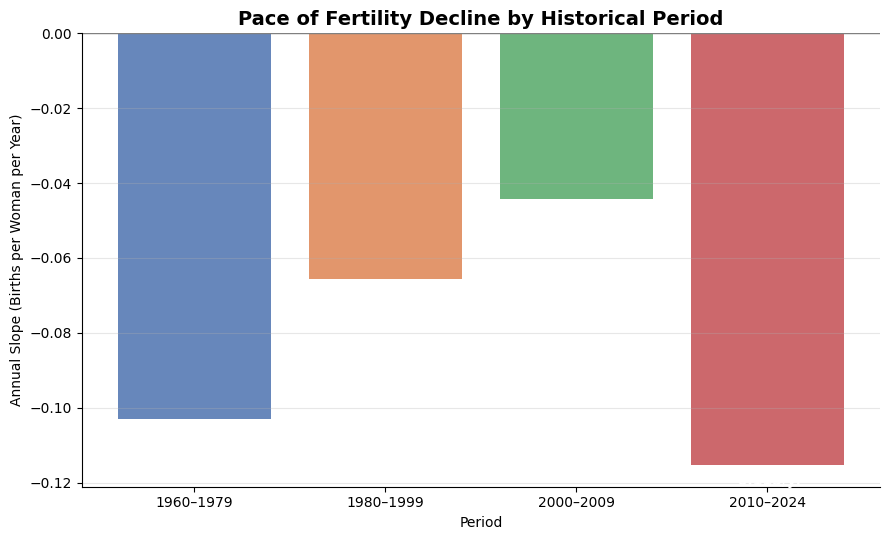

In [46]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bar_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = ax.bar(period_summary["Period"], period_summary["Annual Slope"], color=bar_colors, alpha=0.85)

for bar, slope in zip(bars, period_summary["Annual Slope"]):
    ax.annotate(f"{slope:+.3f}/yr", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, -14 if slope < 0 else 6), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold",
                color="white" if slope < 0 else "black")

ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Pace of Fertility Decline by Historical Period", fontsize=14, fontweight="bold")
ax.set_ylabel("Annual Slope (Births per Woman per Year)")
ax.set_xlabel("Period")
ax.grid(alpha=0.3, axis="y")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

The bar chart translates the structural-change slopes into a single, direct visual comparison. The pace of decline was steep in 1960–1979 (−0.103/yr), softened through 1980–1999 (−0.066/yr), and nearly stalled in 2000–2009 (−0.044/yr), before becoming the steepest period on record in 2010–2024 (−0.115/yr) — even faster than the original 1960s decline.

This U-shaped pattern is itself evidence against a "simply declining" story. A single demographic process moving at a roughly constant pace would not produce a slowdown followed by an acceleration that exceeds its own starting speed. The fact that the rate of change reorganized itself this dramatically across periods points toward a shift in the underlying demographic behavior — not just a continuation of one trend.

### Why Might the Pace Have Shifted? A Plausible (Untested) Explanation

The statistical evidence in this notebook- non-stationarity, a changing pace of decline, and persistent low-frequency structure in the detrended residuals- describes *that* the underlying fertility process changed. It does not, on its own, explain *why*.

Philippine demographic literature offers several candidate explanations for the post-2010 acceleration in particular:

* **The Responsible Parenthood and Reproductive Health Act (RH Law), signed in 2012,** expanded access to modern family planning methods and reproductive health services nationwide — plausibly coinciding with, and possibly contributing to, the steep decline observed in the 2010–2024 period.
* **Rising urbanization** has shifted a growing share of the population into urban settings, where fertility rates are consistently lower than in rural areas.
* **Expanding female educational attainment and labor-force participation** are well-documented drivers of delayed marriage and childbearing in demographic transition theory.

These are offered as plausible contextual explanations drawn from the broader demographic literature, not as claims tested by this notebook's time-series analysis — establishing a causal link would require a different kind of study (e.g., a policy-evaluation or panel-regression design). What this notebook *does* establish, statistically, is that the fertility process itself was not stable across the 65-year record, leaving room for exactly this kind of structural, policy-linked explanation rather than only random year-to-year variation.

---

The Philippines did not simply experience temporary periods of unusually low fertility. The historical record shows that what was once normal—nearly seven children per woman—has gradually been replaced by a fundamentally different demographic reality.

### Summary Matrix of Time-Series Findings


| Characteristic         | What We Observe                     | Interpretation                                           |
| ---------------------- | ----------------------------------- | -------------------------------------------------------- |
| **Trend**              | Persistent decline from ~7 to ~1.89 | Strong downward long-term trend                          |
| **Stationarity**       | ADF p ≈ 0.65                        | Original series is non-stationary                        |
| **After Differencing** | ADF p ≈ 0.002                       | Changes are more stationary than levels                  |
| **Seasonality**        | Annual data only                    | Cannot meaningfully observe within-year seasonality      |
| **Structural Change**  | Pace of decline varies by period    | Possible changes in demographic behavior                 |
| **Cyclicity**          | Long-wavelength residual persists after polynomial detrending (R² 0.9828→0.9871) | Some low-frequency structure likely, but too few repetitions (~65 yrs) to confirm a true repeating cycle |
| **Noise**              | Small annual movements              | Noise is relatively small compared with long-term change |
